In [25]:
# ============================================================
# DEEP LEARNING & NLP LAB
# EXPERIMENT 3A
# CNN FOR IMAGE CLASSIFICATION USING CIFAR-10
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import tarfile
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.21.0


In [26]:
# ============================================================
# 2. CIFAR-10 DATASET SETUP
# ============================================================

print("\n" + "=" * 60)
print("CIFAR-10 DATASET SETUP")
print("=" * 60)

print("""
Download the CIFAR-10 archive from the Google Drive link
provided by your faculty.

After downloading, enter the FULL PATH of the downloaded file.

Example for Mac:
 /Users/YourName/Downloads/cifar-10-batches-py-target_archive

Example for Windows:
 C:/Users/YourName/Downloads/cifar-10-batches-py-target_archive

You can also drag the file from Finder/File Explorer
into the notebook cell to get its path.
""")

archive_path = input(
    "Enter the full path of the CIFAR-10 archive: "
).strip()

# Remove quotes if the student copied the path with quotes
archive_path = archive_path.strip("'\"")



CIFAR-10 DATASET SETUP

Download the CIFAR-10 archive from the Google Drive link
provided by your faculty.

After downloading, enter the FULL PATH of the downloaded file.

Example for Mac:
 /Users/YourName/Downloads/cifar-10-batches-py-target_archive

Example for Windows:
 C:/Users/YourName/Downloads/cifar-10-batches-py-target_archive

You can also drag the file from Finder/File Explorer
into the notebook cell to get its path.




CIFAR-10 archive found!
File size: 162.6 MB

Extracting CIFAR-10 dataset...


/var/folders/k7/qf3f9q597xn2mp2cyfn2l_9h0000gn/T/ipykernel_7613/2592559619.py:48: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(


Extraction completed!

CIFAR-10 data location:
/Users/karthibalasundaram/Downloads/cifar10_dataset/cifar-10-batches-py

Loading CIFAR-10 data...

Dataset loaded successfully!
Training images : (50000, 32, 32, 3)
Training labels : (50000,)
Testing images  : (10000, 32, 32, 3)
Testing labels  : (10000,)


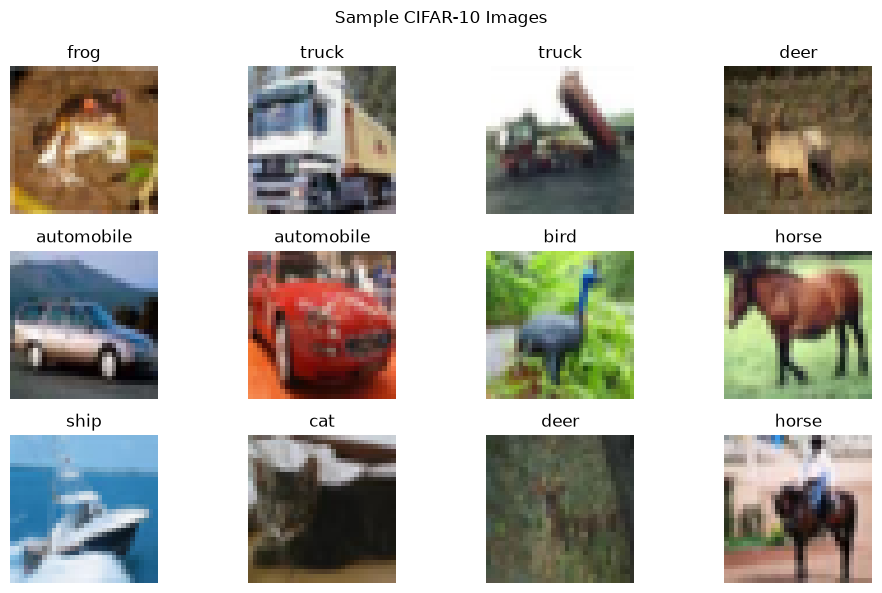


Normalization completed.
Pixel value range: 0.0 to 1.0

BUILDING CNN MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,658 (2.26 MB)

 Trainable params: 591,466 (2.26 MB)

 Non-trainable params: 192 (768.00 B)


Model compiled successfully.

TRAINING CNN
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 48s 133ms/step - accuracy: 0.2192 - loss: 2.0747 - val_accuracy: 0.1424 - val_loss: 2.2498
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.2684 - loss: 1.8463 - val_accuracy: 0.3686 - val_loss: 1.6356
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 139ms/step - accuracy: 0.2963 - loss: 1.7448 - val_accuracy: 0.4314 - val_loss: 1.5565
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.3452 - loss: 1.6401 - val_accuracy: 0.5168 - val_loss: 1.3211
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.3700 - loss: 1.5778 - val_accuracy: 0.5402 - val_loss: 1.3335

MODEL EVALUATION
Test Loss: 1.366
Test Accuracy: 0.521
Test Accuracy (%): 52.1 %


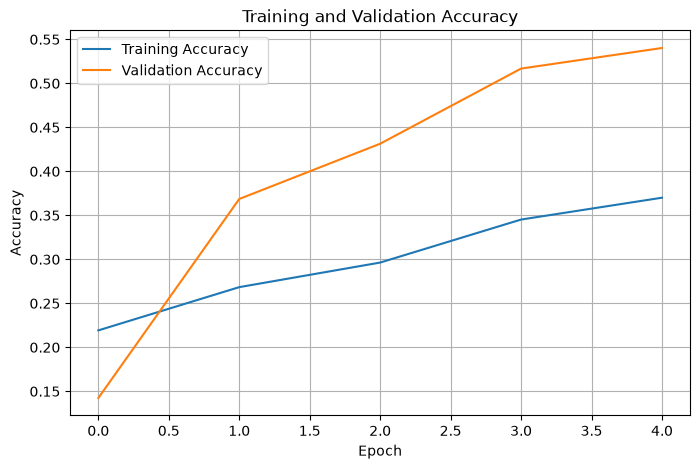

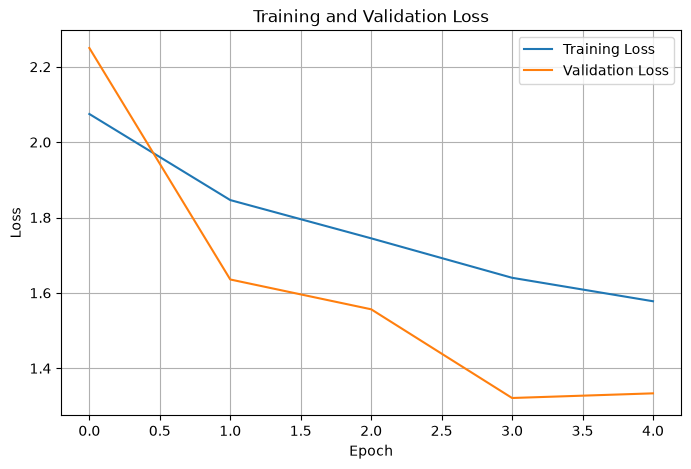


Generating predictions...
Predictions generated successfully.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane       0.49      0.69      0.57      1000
  automobile       0.58      0.48      0.53      1000
        bird       0.42      0.25      0.32      1000
         cat       0.33      0.37      0.35      1000
        deer       0.47      0.46      0.46      1000
         dog       0.58      0.41      0.48      1000
        frog       0.86      0.47      0.61      1000
       horse       0.52      0.71      0.60      1000
        ship       0.66      0.79      0.72      1000
       truck       0.45      0.58      0.51      1000

    accuracy                           0.52     10000
   macro avg       0.54      0.52      0.51     10000
weighted avg       0.54      0.52      0.51     10000



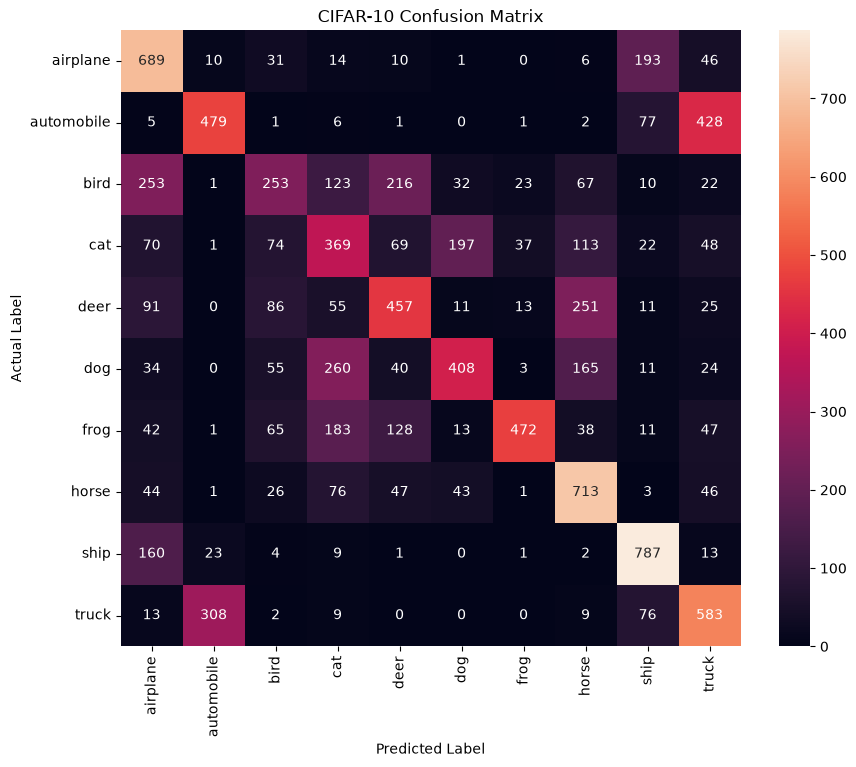

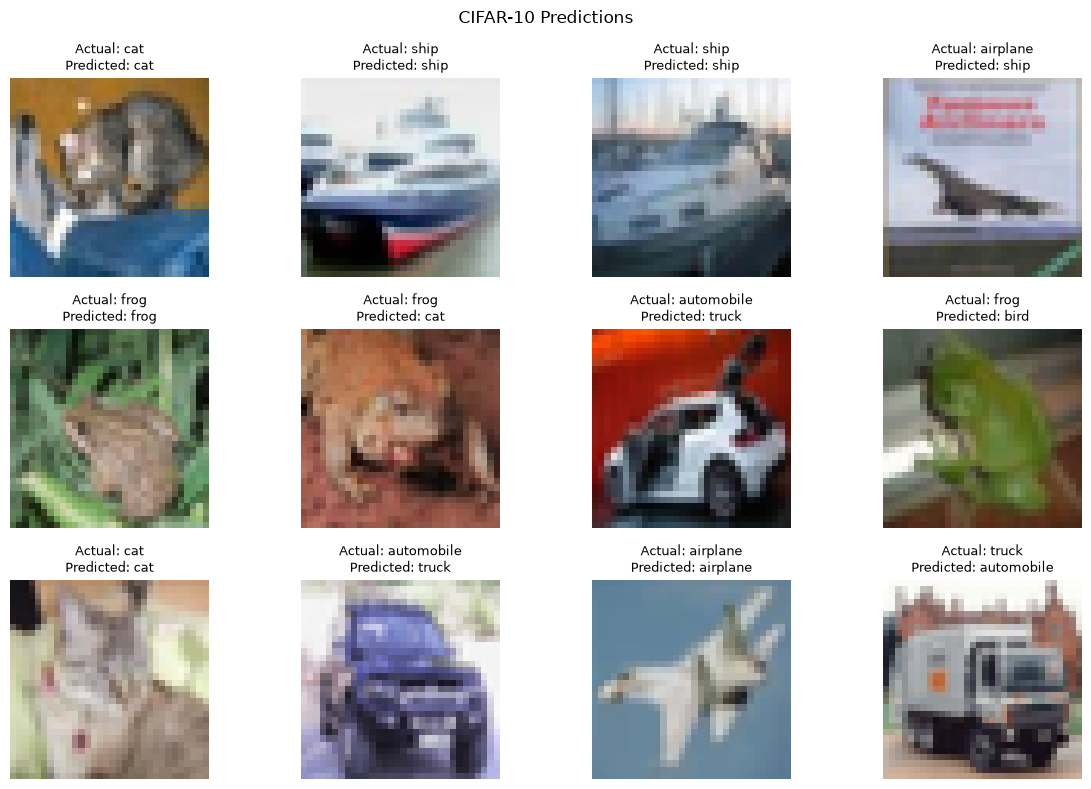

In [27]:
# ============================================================
# 3. CHECK FILE
# ============================================================

if not os.path.isfile(archive_path):

    print("\nERROR: File not found!")
    print("\nYou entered:")
    print(archive_path)

    print("\nPlease check:")
    print("1. Did you download the CIFAR-10 file?")
    print("2. Is the path correct?")
    print("3. Did you include the complete filename?")

    raise FileNotFoundError(
        "CIFAR-10 archive was not found."
    )

else:

    file_size_mb = os.path.getsize(archive_path) / (1024 * 1024)

    print("\nCIFAR-10 archive found!")
    print("File size:", round(file_size_mb, 2), "MB")


# ============================================================
# 4. EXTRACT CIFAR-10 DATASET
# ============================================================

extraction_folder = os.path.join(
    os.path.dirname(archive_path),
    "cifar10_dataset"
)

print("\nExtracting CIFAR-10 dataset...")

if not os.path.exists(extraction_folder):

    os.makedirs(extraction_folder)

    with tarfile.open(
        archive_path,
        "r:*"
    ) as tar:

        tar.extractall(
            path=extraction_folder
        )

    print("Extraction completed!")

else:

    print(
        "Dataset folder already exists."
    )


# ============================================================
# 5. FIND CIFAR-10 DATA FOLDER
# ============================================================

cifar_folder = None

for root, dirs, files in os.walk(extraction_folder):

    if "data_batch_1" in files:

        cifar_folder = root
        break


if cifar_folder is None:

    raise FileNotFoundError(
        "Could not find the CIFAR-10 files after extraction."
    )


print("\nCIFAR-10 data location:")
print(cifar_folder)


# ============================================================
# 6. LOAD CIFAR-10 USING KERAS INTERNAL FORMAT
# ============================================================

print("\nLoading CIFAR-10 data...")


def load_cifar_batch(file):

    import pickle

    with open(file, "rb") as fo:

        data_dict = pickle.load(
            fo,
            encoding="bytes"
        )

    data = data_dict[b"data"]

    labels = data_dict[b"labels"]

    data = data.reshape(
        -1,
        3,
        32,
        32
    )

    data = data.transpose(
        0,
        2,
        3,
        1
    )

    return data, np.array(labels)


# ------------------------------------------------------------
# Load training batches
# ------------------------------------------------------------

X_train_list = []
y_train_list = []

for i in range(1, 6):

    file_path = os.path.join(
        cifar_folder,
        f"data_batch_{i}"
    )

    X_batch, y_batch = load_cifar_batch(
        file_path
    )

    X_train_list.append(X_batch)
    y_train_list.append(y_batch)


X_train = np.concatenate(
    X_train_list,
    axis=0
)

y_train = np.concatenate(
    y_train_list,
    axis=0
)


# ------------------------------------------------------------
# Load test batch
# ------------------------------------------------------------

test_file = os.path.join(
    cifar_folder,
    "test_batch"
)

X_test, y_test = load_cifar_batch(
    test_file
)


print("\nDataset loaded successfully!")

print("Training images :", X_train.shape)
print("Training labels :", y_train.shape)

print("Testing images  :", X_test.shape)
print("Testing labels  :", y_test.shape)


# ============================================================
# 7. CLASS NAMES
# ============================================================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# ============================================================
# 8. DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_train[i])

    plt.title(
        class_names[y_train[i]]
    )

    plt.axis("off")

plt.suptitle(
    "Sample CIFAR-10 Images"
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. NORMALIZE IMAGES
# ============================================================

X_train = X_train.astype(
    "float32"
) / 255.0

X_test = X_test.astype(
    "float32"
) / 255.0

print("\nNormalization completed.")

print(
    "Pixel value range:",
    X_train.min(),
    "to",
    X_train.max()
)


# ============================================================
# 10. BUILD CNN MODEL
# ============================================================

print("\n" + "=" * 60)
print("BUILDING CNN MODEL")
print("=" * 60)


model = Sequential([

    Input(
        shape=(32, 32, 3)
    ),

    # -------------------------
    # Convolution Block 1
    # -------------------------

    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Dropout(0.25),


    # -------------------------
    # Convolution Block 2
    # -------------------------

    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Dropout(0.25),


    # -------------------------
    # Classification
    # -------------------------

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 11. MODEL SUMMARY
# ============================================================

model.summary()


# ============================================================
# 12. COMPILE MODEL
# ============================================================

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("\nModel compiled successfully.")


# ============================================================
# 13. TRAIN MODEL
# ============================================================

print("\n" + "=" * 60)
print("TRAINING CNN")
print("=" * 60)

history = model.fit(

    X_train,

    y_train,

    epochs=5,

    batch_size=128,

    validation_split=0.1,

    verbose=1
)


# ============================================================
# 14. EVALUATE MODEL
# ============================================================

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(

    X_test,

    y_test,

    verbose=0
)


print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

print(
    "Test Accuracy (%):",
    round(test_accuracy * 100, 2),
    "%"
)


# ============================================================
# 15. ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 16. LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 17. MAKE PREDICTIONS
# ============================================================

print("\nGenerating predictions...")

y_pred = model.predict(

    X_test,

    verbose=0
)

y_pred_classes = np.argmax(

    y_pred,

    axis=1
)

print(
    "Predictions generated successfully."
)


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(

    classification_report(

        y_test,

        y_pred_classes,

        target_names=class_names

    )

)


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred_classes

)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "CIFAR-10 Confusion Matrix"
)

plt.show()


# ============================================================
# 20. SAMPLE PREDICTIONS
# ============================================================

plt.figure(
    figsize=(12, 8)
)

for i in range(12):

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        X_test[i]
    )

    actual = class_names[
        y_test[i]
    ]

    predicted = class_names[
        y_pred_classes[i]
    ]

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}",
        fontsize=9
    )

    plt.axis("off")


plt.suptitle(
    "CIFAR-10 Predictions"
)

plt.tight_layout()

plt.show()




Extracting feature maps...
Feature map shape: (1, 32, 32, 32)


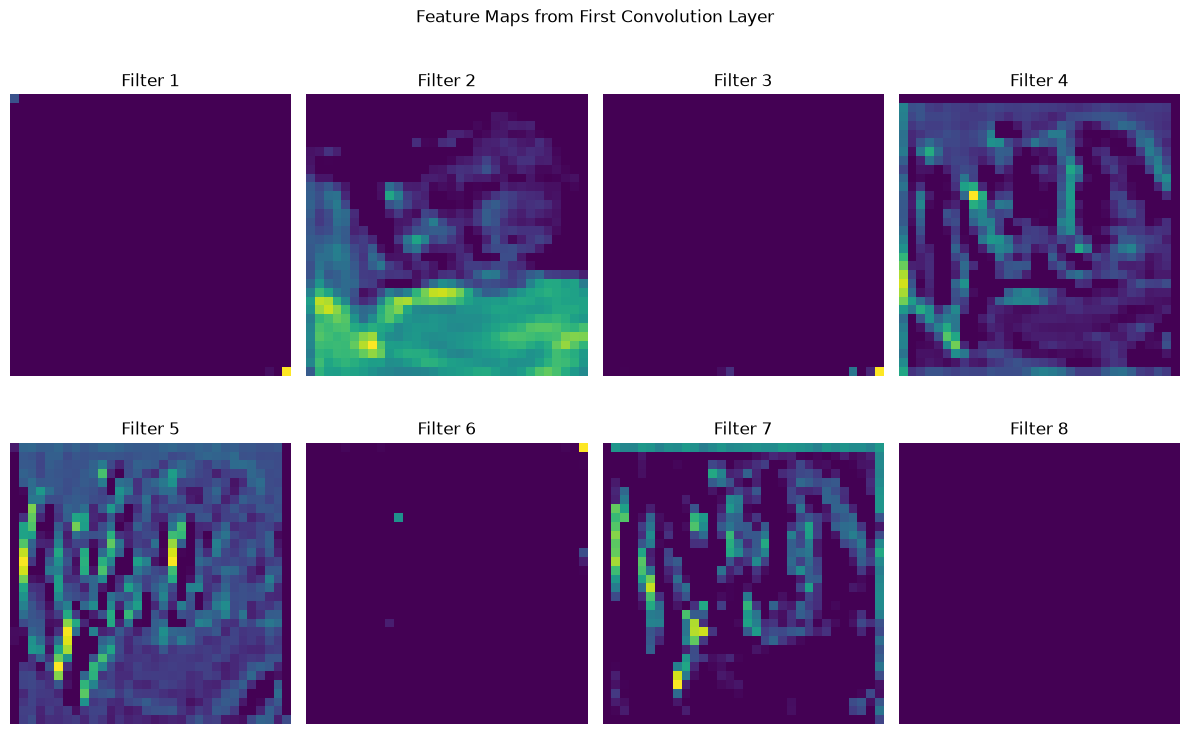


SINGLE IMAGE PREDICTION
Actual Class: deer
Predicted Class: deer
Confidence: 42.53 %


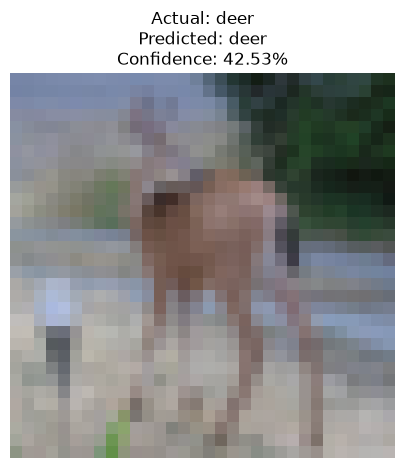


EXPERIMENT 3A COMPLETED
Dataset       : CIFAR-10
Training Data : (50000, 32, 32, 3)
Testing Data  : (10000, 32, 32, 3)
Test Accuracy : 52.1 %
Evaluation    : Classification Report + Confusion Matrix
Visualization : Feature Maps

Experiment completed successfully!


In [28]:
# ============================================================
# 21. FEATURE MAP EXTRACTION
# ============================================================

print("\nExtracting feature maps...")

# Use the model's explicit Input layer
feature_model = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=model.layers[0].output
)

sample_image = X_test[0:1]

feature_maps = feature_model.predict(
    sample_image,
    verbose=0
)

print("Feature map shape:", feature_maps.shape)


# ============================================================
# 22. VISUALIZE FEATURE MAPS
# ============================================================

plt.figure(
    figsize=(12, 8)
)

for i in range(8):

    plt.subplot(
        2,
        4,
        i + 1
    )

    plt.imshow(

        feature_maps[0, :, :, i],

        cmap="viridis"

    )

    plt.title(
        f"Filter {i + 1}"
    )

    plt.axis("off")


plt.suptitle(
    "Feature Maps from First Convolution Layer"
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. SINGLE IMAGE PREDICTION
# ============================================================

index = 100

image = X_test[index]


prediction = model.predict(

    image.reshape(
        1,
        32,
        32,
        3
    ),

    verbose=0

)


predicted_class = np.argmax(
    prediction
)


confidence = (
    float(
        np.max(prediction)
    ) * 100
)


print("\n" + "=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

print(
    "Actual Class:",
    class_names[y_test[index]]
)

print(
    "Predicted Class:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    round(
        confidence,
        2
    ),
    "%"
)


plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    image
)

plt.title(

    f"Actual: {class_names[y_test[index]]}\n"
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"

)

plt.axis("off")

plt.show()


# ============================================================
# 24. FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT 3A COMPLETED")
print("=" * 60)

print(
    "Dataset       : CIFAR-10"
)

print(
    "Training Data :",
    X_train.shape
)

print(
    "Testing Data  :",
    X_test.shape
)

print(
    "Test Accuracy :",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Evaluation    : Classification Report + Confusion Matrix"
)

print(
    "Visualization : Feature Maps"
)

print("\nExperiment completed successfully!")